# EfficientNet-B0 Experiment 08 — Focal Loss

## Objective
Iteration 05 (the best single-model result) used `BCEWithLogitsLoss` with `pos_weight=8.1` to handle class imbalance. The core problem with this approach is that easy-to-classify nevus samples dominate the gradient signal every epoch — they are abundant, the model is already confident on them, yet they still contribute equally to the loss as hard borderline cases. Focal Loss (Lin et al., 2017) addresses this directly by down-weighting easy examples via a modulating factor `(1 - p_t)^γ`, forcing training to focus on hard, uncertain samples regardless of class. The α parameter replaces `pos_weight` for class imbalance correction. All other components are held constant relative to Iter 05 to isolate the effect of the loss function.

## Architecture Changes

| Component | Iter 05 (Aug + L1 + Dropout + Metadata) | Iter 08 (Focal Loss) |
|---|---|---|
| Variant | EfficientNet-B0 | EfficientNet-B0 |
| Unfrozen blocks | Last 6 of `features` | Last 6 of `features` |
| Loss | BCEWithLogitsLoss | **BinaryFocalLoss (γ=2.0, α=0.89)** |
| pos_weight | 8.1 | **None (replaced by focal α)** |
| Label smoothing | None | None |
| Sampler | Random shuffle | Random shuffle |
| Weight decay | 1e-3 | 1e-3 |
| L1 lambda | 1e-3 | 1e-3 |
| L2 lambda | 0 | 0 |
| Dropout | 0.5 | 0.5 |
| Patient metadata | age + sex + localization (dim=17) | age + sex + localization (dim=17) |
| LR — backbone | 1e-4 | 1e-4 |
| LR — head | 1e-3 | 1e-3 |
| Scheduler | CosineAnnealingLR | CosineAnnealingLR |
| Epochs | 30 | 30 |

## Hypothesis
Focal loss will reduce the disproportionate influence of the large pool of easy nevus examples on the gradient, focusing capacity on hard borderline cases where the model is uncertain. The α=0.89 term (derived from class frequencies) maintains the same class-imbalance correction as pos_weight=8.1. The focusing factor γ=2.0 should also act as an implicit regulariser — because easy samples contribute near-zero loss, the effective gradient signal is less noisy, potentially shrinking the train/val gap seen in Iter 05 without requiring explicit changes to the sampler or label targets.

## Import libraries, set seed, and choose device

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000DatasetWithMetadata
from src.data.transform import get_augmented_train_transforms, get_eval_transforms
from src.models.efficientnet import EfficientNetB0WithMetadata
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model
from src.utils import seed_everything, seed_worker

import pandas as pd

g = seed_everything(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
METADATA_PATH      = str(ROOT / 'data_new/raw/HAM10000_metadata')
TEST_METADATA_PATH = str(ROOT / 'data_new/raw/ISIC2018_Task3_Test_GroundTruth.csv')

train_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    metadata_path=METADATA_PATH,
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    worker_init_fn=seed_worker,
    generator=g,
)

val_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/val.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    metadata_path=METADATA_PATH,
    transform=get_eval_transforms(image_size=224),
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
)

test_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/test'),
    metadata_path=TEST_METADATA_PATH,
    transform=get_eval_transforms(image_size=224),
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')
print(f'Melanoma: {num_melanoma} | Nevus: {num_nevus} | Ratio: 1:{num_nevus/num_melanoma:.1f}')

Train: 7991 | Val: 2024 | Test: 1511
Melanoma: 877 | Nevus: 7114 | Ratio: 1:8.1


## Model Definition

In [3]:
class BinaryFocalLoss(nn.Module):
    """Focal Loss for binary classification (Lin et al., 2017).

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Args:
        gamma: focusing parameter. gamma=0 reduces to standard BCE.
               gamma=2 is the standard value from the paper.
        alpha: weight for the positive (melanoma) class.
               Set to num_nevus / total to match class frequency.
    """
    def __init__(self, gamma: float = 2.0, alpha: float = 0.75):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t = torch.exp(-bce)                          # probability of correct class
        focal_weight = (1.0 - p_t) ** self.gamma       # down-weight easy examples
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        loss = alpha_t * focal_weight * bce
        return loss.mean()


METADATA_DIM      = 17
DROPOUT           = 0.5
UNFREEZE_N_BLOCKS = 6
FOCAL_GAMMA       = 2.0
FOCAL_ALPHA       = num_nevus / (num_melanoma + num_nevus)  # ~0.89

model = EfficientNetB0WithMetadata(
    metadata_dim=METADATA_DIM,
    num_classes=1,
    freeze_backbone=True,
    dropout=DROPOUT,
).to(device)

for block in list(model.features)[-UNFREEZE_N_BLOCKS:]:
    for param in block.parameters():
        param.requires_grad = True

criterion = BinaryFocalLoss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA)

unfrozen_params = [p for block in list(model.features)[-UNFREEZE_N_BLOCKS:]
                   for p in block.parameters()]
optimizer = optim.AdamW([
    {'params': unfrozen_params,                  'lr': 1e-4},
    {'params': model.meta_encoder.parameters(),  'lr': 1e-3},
    {'params': model.head.parameters(),          'lr': 1e-3},
], weight_decay=1e-3)

num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

L1_LAMBDA = 1e-3
L2_LAMBDA = 0.0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | Dropout: {DROPOUT} | Focal gamma: {FOCAL_GAMMA} | Focal alpha: {FOCAL_ALPHA:.4f}')

Trainable params: 3,990,347 / 4,009,437
L1 lambda: 0.001 | Dropout: 0.5 | Focal gamma: 2.0 | Focal alpha: 0.8903


## Training Loop

In [4]:
best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA, use_metadata=True,
    )
    val_metrics = validate_one_epoch(model, val_loader, criterion, device, use_metadata=True)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/efficientnet_b0_focal_loss_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/30]
  Train | Loss: 0.0295, Bal Acc: 0.6937, Recall: 0.7412, F2: 0.4869, AUC: 0.7462
  Val   | Loss: 0.0269, Bal Acc: 0.7502, Recall: 0.8220, F2: 0.5663, AUC: 0.8224
  -> Saved best model (val AUC: 0.8224)


Epoch [2/30]
  Train | Loss: 0.0276, Bal Acc: 0.7197, Recall: 0.7834, F2: 0.5172, AUC: 0.7938
  Val   | Loss: 0.0250, Bal Acc: 0.7503, Recall: 0.9110, F2: 0.5679, AUC: 0.8583
  -> Saved best model (val AUC: 0.8583)


Epoch [3/30]
  Train | Loss: 0.0271, Bal Acc: 0.7290, Recall: 0.8210, F2: 0.5286, AUC: 0.8014
  Val   | Loss: 0.0261, Bal Acc: 0.7340, Recall: 0.9322, F2: 0.5517, AUC: 0.8336


Epoch [4/30]
  Train | Loss: 0.0270, Bal Acc: 0.7249, Recall: 0.8107, F2: 0.5238, AUC: 0.8013
  Val   | Loss: 0.0275, Bal Acc: 0.7477, Recall: 0.8305, F2: 0.5635, AUC: 0.8080


Epoch [5/30]
  Train | Loss: 0.0263, Bal Acc: 0.7288, Recall: 0.8141, F2: 0.5283, AUC: 0.8104
  Val   | Loss: 0.0259, Bal Acc: 0.7307, Recall: 0.8686, F2: 0.5461, AUC: 0.8374


...

Epoch [26/30]
  Train | Loss: 0.0246, Bal Acc: 0.7525, Recall: 0.8495, F2: 0.5556, AUC: 0.8346
  Val   | Loss: 0.0230, Bal Acc: 0.7860, Recall: 0.9025, F2: 0.6093, AUC: 0.8742
  -> Saved best model (val AUC: 0.8742)


Epoch [27/30]
  Train | Loss: 0.0243, Bal Acc: 0.7667, Recall: 0.8575, F2: 0.5726, AUC: 0.8382
  Val   | Loss: 0.0233, Bal Acc: 0.7732, Recall: 0.9407, F2: 0.5933, AUC: 0.8728


Epoch [28/30]
  Train | Loss: 0.0243, Bal Acc: 0.7628, Recall: 0.8449, F2: 0.5682, AUC: 0.8401
  Val   | Loss: 0.0234, Bal Acc: 0.7751, Recall: 0.9407, F2: 0.5955, AUC: 0.8714


Epoch [29/30]
  Train | Loss: 0.0240, Bal Acc: 0.7655, Recall: 0.8666, F2: 0.5710, AUC: 0.8448
  Val   | Loss: 0.0232, Bal Acc: 0.7789, Recall: 0.9280, F2: 0.6000, AUC: 0.8730


Epoch [30/30]
  Train | Loss: 0.0239, Bal Acc: 0.7682, Recall: 0.8677, F2: 0.5743, AUC: 0.8477
  Val   | Loss: 0.0231, Bal Acc: 0.7790, Recall: 0.9237, F2: 0.6002, AUC: 0.8728


## Plot Train and Validation Curves

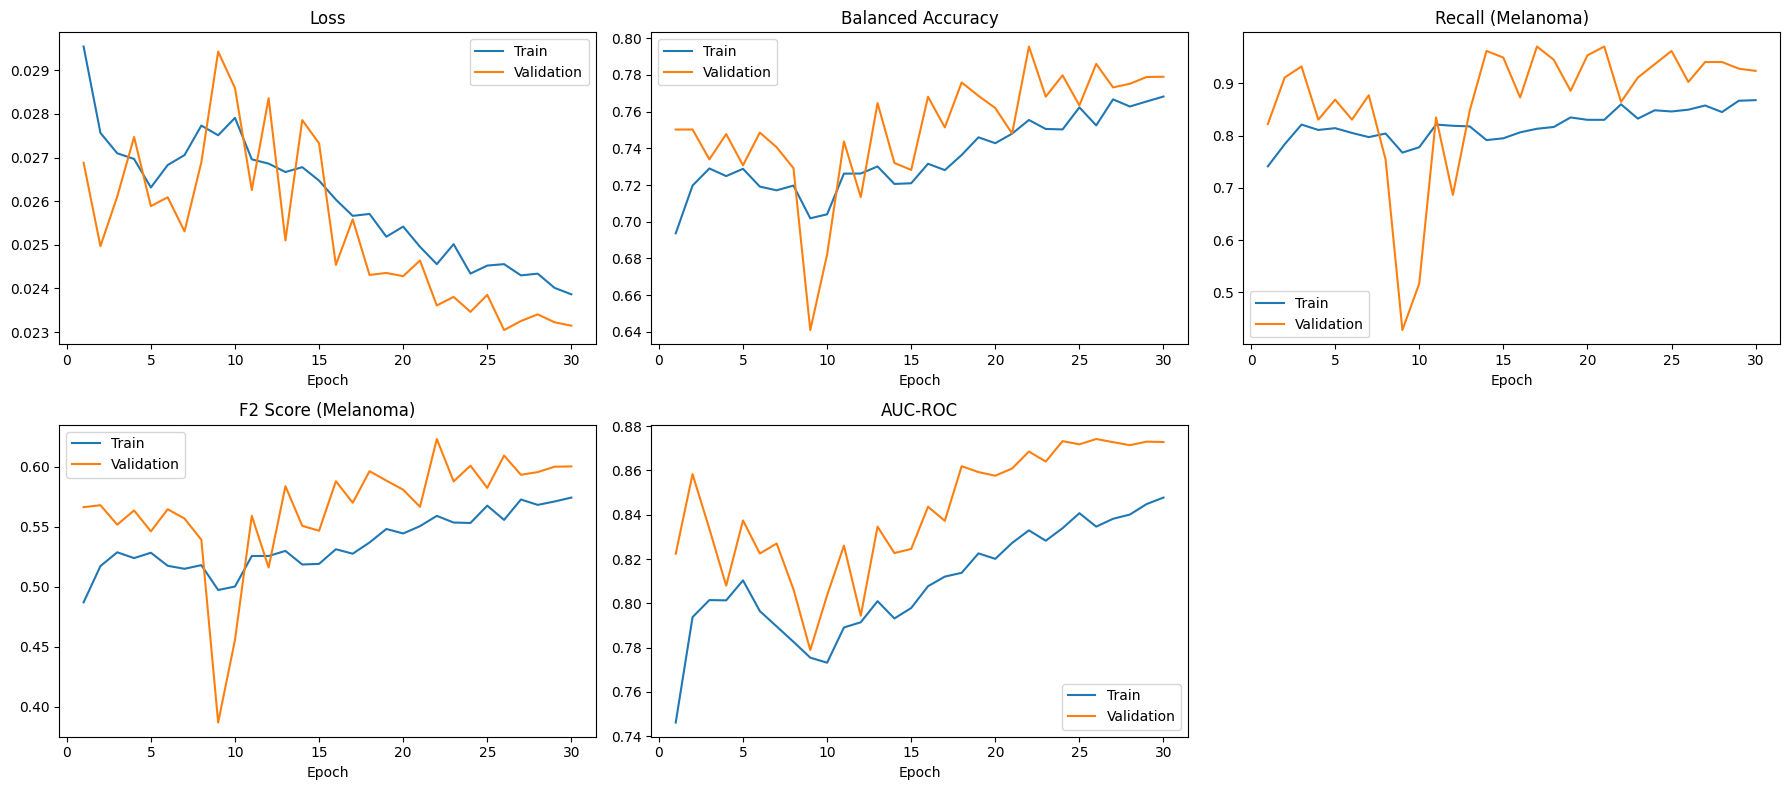

In [5]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [6]:
model.load_state_dict(torch.load(str(ROOT / 'models/efficientnet_b0_focal_loss_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device, use_metadata=True)

Best threshold: 0.54 | Val F2: 0.6250


## Test Set Evaluation

Threshold:          0.54
AUC-ROC:            0.8518
Balanced Accuracy:  0.7658
F2 Score:           0.5806

              precision    recall  f1-score   support

Non-Melanoma     0.9595    0.7948    0.8694      1340
    Melanoma     0.3142    0.7368    0.4406       171

    accuracy                         0.7882      1511
   macro avg     0.6368    0.7658    0.6550      1511
weighted avg     0.8864    0.7882    0.8209      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


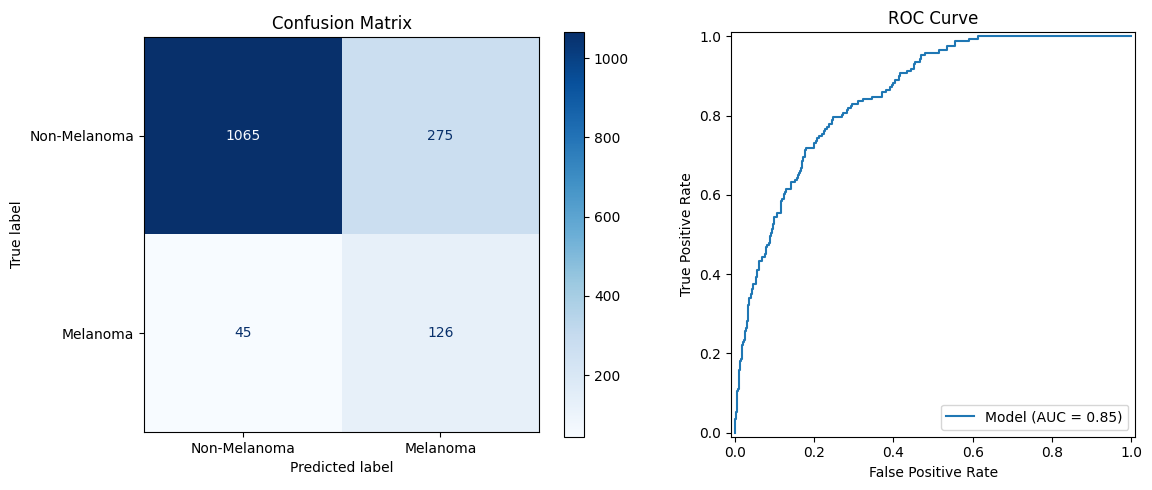

In [7]:
evaluate_model(model, test_loader, device, threshold=best_threshold, use_metadata=True)